In [1]:
#Import Packages
import pandas as pd
import seaborn as sns
import numpy as np

import time
import sys
import matplotlib.pyplot as plt
import math
import os

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import MiniBatchKMeans
from sklearn.cluster import KMeans

In [2]:
!git clone https://github.com/HickeyLab/Hierarchical-Tissue-Unit-Annotation.git

fatal: destination path 'Hierarchical-Tissue-Unit-Annotation' already exists and is not an empty directory.


In [2]:
#Import Neighborhood Functions and Code
cellhier_path = 'Hierarchical-Tissue-Unit-Annotation/'
sys.path.append(cellhier_path)
from cellhier.general import *
from cellhier.plot_john import *
from cellhier.knn_graph_neighborhood2 import *  # Imports everything

In [3]:
# Initialize list to hold DataFrames
dfs = []

# Loop through all 31 files
for i in range(1, 32):  # range is exclusive at the end
    file_path = f"/content/{i}.csv"

    # Read the CSV file
    df = pd.read_csv(file_path)

    # Append to list
    dfs.append(df)

# Concatenate all DataFrames into one
cells = pd.concat(dfs, ignore_index=True)
cells

,Cell Type,x,y,unique_region
0,ICC,175,0,1
1,Enterocyte,176,0,1
2,Enterocyte,177,0,1
3,Enterocyte,178,0,1
4,Lymphatic,185,0,1
...,...,...,...,...
1357700,Neutrophil,429,511,31
1357701,Smooth muscle,431,511,31
1357702,Lymphatic,435,511,31
1357703,Stroma,439,511,31


In [4]:
cells['unique_region'] = cells['unique_region'].astype(str)
cells['Cell Type'] = cells['Cell Type'].astype(str)
cells.reset_index(inplace=True, drop=True)
cells

,Cell Type,x,y,unique_region
0,ICC,175,0,1
1,Enterocyte,176,0,1
2,Enterocyte,177,0,1
3,Enterocyte,178,0,1
4,Lymphatic,185,0,1
...,...,...,...,...
1357700,Neutrophil,429,511,31
1357701,Smooth muscle,431,511,31
1357702,Lymphatic,435,511,31
1357703,Stroma,439,511,31


In [5]:
cells['Cell Type'].unique()

array(['ICC', 'Enterocyte', 'Lymphatic', 'Endothelial', 'M2 Macrophage',
       'Stroma', 'CD4+ T cell', 'Cycling TA', 'Goblet', 'TA',
       'Neuroendocrine', 'CD8+ T', 'Paneth', 'Smooth muscle', 'Nerve',
       'CD66+ Enterocyte', 'Plasma', 'CD7+ Immune', 'DC', 'NK',
       'Neutrophil', 'M1 Macrophage', 'B', 'MUC1+ Enterocyte',
       'CD57+ Enterocyte'], dtype=object)

In [7]:
#Function for getting neighborhood windows

def get_windows(job, n_neighbors):

    # Unpack the job tuple containing start_time, idx, tissue_name, and indices
    start_time, idx, tissue_name, indices = job

    # Record the current time to measure the duration of the job
    job_start = time.time()

    # Print a message indicating the start of the job
    print("Starting:", str(idx+1)+'/'+str(len(exps)), ': ' + exps[idx])

    # Get the subset of the dataset for the specific tissue
    tissue = tissue_group.get_group(tissue_name)

    # Extract the coordinates (X, Y) for the points to be fitted from the tissue subset
    to_fit = tissue.loc[indices][[X, Y]].values

    # Fit the NearestNeighbors model on the tissue's X, Y coordinates
    fit = NearestNeighbors(n_neighbors=n_neighbors).fit(tissue[[X, Y]].values)

    # Find the nearest neighbors for the points in 'to_fit'
    m = fit.kneighbors(to_fit)

    # Sort the neighbors
    # 'args' are the indices that would sort the distances
    args = m[0].argsort(axis=1)

    # 'add' is used to adjust indices for flattened array
    add = np.arange(m[1].shape[0]) * m[1].shape[1]

    # Calculate sorted indices for neighbors
    sorted_indices = m[1].flatten()[args + add[:, None]]

    # Retrieve the neighbor indices from the tissue dataset
    neighbors = tissue.index.values[sorted_indices]

    # Record the end time of the job
    end_time = time.time()

    # Print a message indicating the end of the job and the duration
    print("Finishing:", str(idx+1)+"/"+str(len(exps)), ": "+ exps[idx], end_time - job_start, end_time - start_time)

    # Return the neighbor indices as an array of integers
    return neighbors.astype(np.int32)


# Define column names that will be used for neighborhood analysis
X = 'x'                  # Variable for the X coordinate
Y = 'y'                  # Variable for the Y coordinate
reg = 'unique_region'         # Variable for the filename or region identifier associated with coordinates
cluster_col = 'Cell Type'  # Variable for cell type/subtype classification

# List of columns to keep for analysis
keep_cols = [X, Y, reg, cluster_col]

# Concatenate the original 'cells' DataFrame with dummy variables created from 'cluster_col'
# pd.get_dummies() converts categorical variable(s) into dummy/indicator variables
cells = pd.concat([cells, pd.get_dummies(cells[cluster_col], dtype=int)], axis=1)

# Get unique values from the 'cluster_col' column to use for summarization
sum_cols = cells[cluster_col].unique()
values = cells[sum_cols].values
ks = [5,10,20] # k=5 means it collects 5 nearest neighbors for each center cell
n_neighbors = max(ks) #sets n_neighbors to max of the list that is set
tissue_group = cells[[X, Y, reg]].groupby(reg)
exps = list(cells[reg].unique())
tissue_chunks = [(time.time(), exps.index(t), t, a) for t, indices in tissue_group.groups.items() for a in np.array_split(indices, 1)]
tissues = [get_windows(job, n_neighbors) for job in tissue_chunks]




Starting: 1/31 : 1
Finishing: 1/31 : 1 0.1679706573486328 0.17136096954345703
Starting: 10/31 : 10
Finishing: 10/31 : 10 0.284595251083374 0.45636653900146484
Starting: 11/31 : 11
Finishing: 11/31 : 11 0.26770710945129395 0.7250328063964844
Starting: 12/31 : 12
Finishing: 12/31 : 12 0.17555975914001465 0.9014952182769775
Starting: 13/31 : 13
Finishing: 13/31 : 13 0.1602640151977539 1.0623836517333984
Starting: 14/31 : 14
Finishing: 14/31 : 14 0.1620171070098877 1.2251603603363037
Starting: 15/31 : 15
Finishing: 15/31 : 15 0.16437721252441406 1.390169382095337
Starting: 16/31 : 16
Finishing: 16/31 : 16 0.19000816345214844 1.581136703491211
Starting: 17/31 : 17
Finishing: 17/31 : 17 0.41510820388793945 1.9968278408050537
Starting: 18/31 : 18
Finishing: 18/31 : 18 0.3484616279602051 2.3499462604522705
Starting: 19/31 : 19
Finishing: 19/31 : 19 0.3649437427520752 2.7178752422332764
Starting: 2/31 : 2
Finishing: 2/31 : 2 0.08631372451782227 2.8057854175567627
Starting: 20/31 : 20
Finishing:

In [8]:
# Initialize a dictionary to store the output
out_dict = {}

# Loop over a list of values 'ks' (different numbers of neighbors to consider)
for k in ks:
    # Iterate over each tissue's neighbors and the corresponding job information
    for neighbors, job in zip(tissues, tissue_chunks):

        # Create an array of indices for the current chunk of data
        chunk = np.arange(len(neighbors))  # equivalent to 0, 1, 2, ..., len(neighbors)-1

        # Extract the tissue name and indices from the job tuple
        tissue_name = job[2]  # Region/filename from the job tuple
        indices = job[3]      # Indices from the job tuple

        # Compute the 'window' - a summary measure for the neighborhood of each cell up to the k-th neighbor
        # Reshape and sum values to get counts of the unique cell type for each cell index
        window = values[neighbors[chunk, :k].flatten()].reshape(len(chunk), k, len(sum_cols)).sum(axis=1)

        # Store the computed window and indices in the output dictionary
        # Keyed by a tuple of (tissue_name, k)
        out_dict[(tissue_name, k)] = (window.astype(np.float16), indices)

# Initialize a dictionary to store the final windows data
windows = {}

# Iterate over each value of k again to process the stored information
for k in ks:

    # Concatenate data for each experiment ('exp') into a DataFrame
    # This DataFrame contains the window data for each cell, indexed by cell indices, for the current value of k
    window = pd.concat([pd.DataFrame(out_dict[(exp, k)][0], index=out_dict[(exp, k)][1].astype(int), columns=sum_cols) for exp in exps], axis=0)

    # Ensure the window data is in the same order as the original cells DataFrame
    window = window.loc[cells.index.values]

    # Concatenate the window data with the original columns specified in 'keep_cols'
    window = pd.concat([cells[keep_cols], window], axis=1)

    # Store the concatenated DataFrame in the 'windows' dictionary, keyed by the current value of k
    windows[k] = window

In [9]:
#Choose k value to analyze and pull out from dictionary of stored results of vectors
k = 10
windows2 = windows[k]
#Add cell type column to output windows dataframe
windows2[cluster_col] = cells[cluster_col]
windows2

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,x,y,unique_region,Cell Type,ICC,Enterocyte,Lymphatic,Endothelial,M2 Macrophage,Stroma,...,CD66+ Enterocyte,Plasma,CD7+ Immune,DC,NK,Neutrophil,M1 Macrophage,B,MUC1+ Enterocyte,CD57+ Enterocyte
0,175,0,1,ICC,1.0,7.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,176,0,1,Enterocyte,1.0,7.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,177,0,1,Enterocyte,1.0,8.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,178,0,1,Enterocyte,1.0,8.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,185,0,1,Lymphatic,0.0,2.0,1.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1357700,429,511,31,Neutrophil,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0
1357701,431,511,31,Smooth muscle,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0
1357702,435,511,31,Lymphatic,0.0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0
1357703,439,511,31,Stroma,0.0,0.0,1.0,1.0,4.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
#Fill in based on above for the number of clusters you want
n_neighborhoods = 20

#return a name of the column for storing the clusters
neighborhood_name = "neighborhood"+str(k)

# Initialize a dictionary to store the centroids for each value of 'k'
k_centroids = {}

# Initialize a MiniBatchKMeans clustering model
# 'n_clusters' is set to 'n_neighborhoods', which is the desired number of clusters
# 'random_state=0' ensures reproducibility of the results
km = MiniBatchKMeans(n_clusters=n_neighborhoods, random_state=0)

# Perform clustering on the data in 'windows2' using the columns specified in 'sum_cols'
# '.values' converts the DataFrame to a NumPy array, which is the input format for KMeans
labels = km.fit_predict(windows2[sum_cols].values)

# Store the centroids of the clusters in the 'k_centroids' dictionary, keyed by 'k'
k_centroids[k] = km.cluster_centers_

# Add the cluster labels to the original 'cells' DataFrame
# 'neighborhood_name' is presumably a column name where these labels will be stored
cells[neighborhood_name] = labels

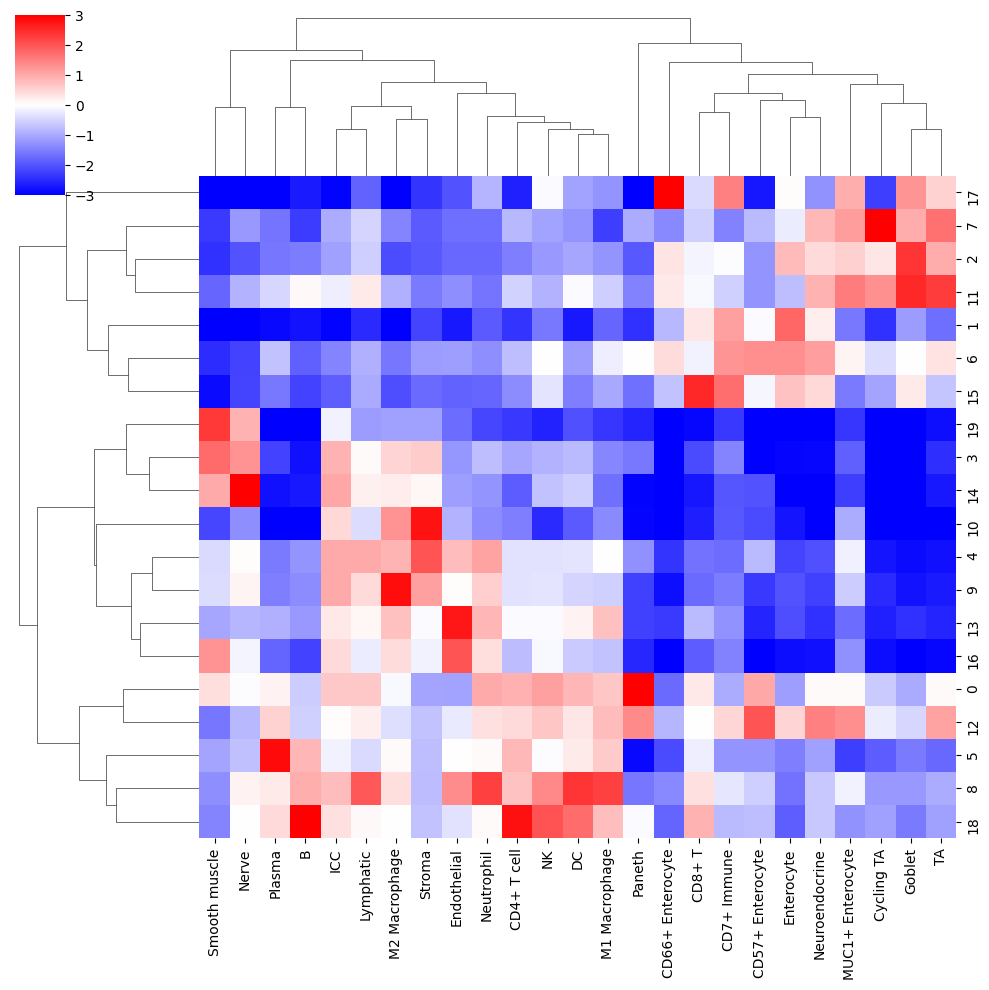

In [16]:
# Select the centroids for a specific value of 'k' for plotting
k_to_plot = k
niche_clusters = (k_centroids[k_to_plot])

# Calculate the average cell types across the 'values' array
tissue_avgs = values.mean(axis=0)

# Compute fold change (fc) of cell types abundance within a neighborhood versus that in the tissue
# This involves a log2 transformation of the ratio of (niche_clusters + tissue_avgs) to tissue_avgs
# The ratio is normalized by the sum across each row (axis=1), ensuring that the sum of ratios for each row is 1
fc = np.log2(((niche_clusters + tissue_avgs) / (niche_clusters + tissue_avgs).sum(axis=1, keepdims=True)) / tissue_avgs)

# Convert the fold change array into a pandas DataFrame for each cell type
fc = pd.DataFrame(fc, columns=sum_cols)

# Create a clustered heatmap using seaborn's clustermap function
# 'fc' DataFrame is used as input
# vmin and vmax set the color scale limits for the heatmap (-3 to 3 in this case)
# cmap='bwr' sets the color palette to blue-white-red
# figsize=(10,10) sets the size of the heatmap
s = sns.clustermap(fc, vmin=-3, vmax=3, cmap='bwr', figsize=(10,10))